# Final Test-Set Evaluation Setup

This notebook prepares final testing on `data/processed/test.csv` for all model families used during validation.

Important leakage rule: thresholds are selected from 5-fold out-of-fold predictions on `train.csv` only. The test set is used only after thresholds are fixed and models are refit on the full training set.

In [1]:
import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    fbeta_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier

In [2]:
# ==========================================
# 1. Load Train and Test Data
# ==========================================

train_df = pd.read_csv("../data/processed/train.csv")
test_df = pd.read_csv("../data/processed/test.csv")

target_column = "Diabetes_01"

X_train = train_df.drop(columns=[target_column])
y_train = train_df[target_column]

X_test = test_df.drop(columns=[target_column])
y_test = test_df[target_column]

data_shape_summary = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "Rows": [len(train_df), len(test_df)],
    "Positive Diabetes Rate": [y_train.mean(), y_test.mean()],
})

data_shape_summary

,Dataset,Rows,Positive Diabetes Rate
0,Train,183824,0.152738
1,Test,45957,0.152751


In [3]:
# ==========================================
# 2. Shared CV and Threshold Helper Functions
# ==========================================

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


def get_best_f2_threshold(y_true, y_score, beta=2):
    precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_true, y_score)
    beta_squared = beta ** 2
    numerator = (1 + beta_squared) * precision_curve[:-1] * recall_curve[:-1]
    denominator = beta_squared * precision_curve[:-1] + recall_curve[:-1]
    fbeta_scores = np.divide(
        numerator,
        denominator,
        out=np.zeros_like(numerator),
        where=denominator != 0,
    )
    return pr_thresholds[fbeta_scores.argmax()]


def get_best_tpr_fpr_threshold(y_true, y_score):
    fpr, tpr, roc_thresholds = roc_curve(y_true, y_score)
    finite_threshold_mask = np.isfinite(roc_thresholds)
    fpr = fpr[finite_threshold_mask]
    tpr = tpr[finite_threshold_mask]
    roc_thresholds = roc_thresholds[finite_threshold_mask]
    best_index = (tpr - fpr).argmax()
    return roc_thresholds[best_index]


def calculate_tpr_fpr(y_true, y_pred):
    true_negative, false_positive, false_negative, true_positive = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
    ).ravel()
    true_positive_rate = true_positive / (true_positive + false_negative)
    false_positive_rate = false_positive / (false_positive + true_negative)
    return true_positive_rate - false_positive_rate


def get_sklearn_scores(estimator, X, score_method):
    if score_method == "predict_proba":
        return estimator.predict_proba(X)[:, 1]
    if score_method == "decision_function":
        return estimator.decision_function(X)
    raise ValueError(f"Unsupported score_method: {score_method}")


def collect_sklearn_oof_scores(model, X, y, score_method):
    fold_predictions = []

    for fold_number, (train_idx, valid_idx) in enumerate(cv_strategy.split(X, y), start=1):
        estimator = clone(model)

        X_fold_train = X.iloc[train_idx]
        y_fold_train = y.iloc[train_idx]
        X_valid = X.iloc[valid_idx]
        y_valid = y.iloc[valid_idx]

        estimator.fit(X_fold_train, y_fold_train)
        y_valid_score = get_sklearn_scores(estimator, X_valid, score_method)

        fold_predictions.append(pd.DataFrame({
            "Fold": fold_number,
            "y_valid": y_valid.to_numpy(),
            "y_valid_score": y_valid_score,
        }))

    return pd.concat(fold_predictions, ignore_index=True)


def build_threshold_table(y_valid, y_valid_score, default_threshold):
    best_f2_threshold = get_best_f2_threshold(y_valid, y_valid_score, beta=2)
    best_tpr_fpr_threshold = get_best_tpr_fpr_threshold(y_valid, y_valid_score)

    return pd.DataFrame([
        {"Threshold Strategy": "Default threshold", "Threshold": default_threshold},
        {"Threshold Strategy": "Max F2 threshold", "Threshold": best_f2_threshold},
        {"Threshold Strategy": "Max TPR-FPR threshold", "Threshold": best_tpr_fpr_threshold},
    ])


def add_test_predictions(prediction_frames, model_name, y_true, y_score, threshold_table):
    for _, threshold_row in threshold_table.iterrows():
        threshold = threshold_row["Threshold"]
        y_pred = (y_score >= threshold).astype(int)

        prediction_frames.append(pd.DataFrame({
            "Model": model_name,
            "Threshold Strategy": threshold_row["Threshold Strategy"],
            "Threshold": threshold,
            "Test Row": np.arange(len(y_true)),
            "y_test": y_true.to_numpy(),
            "y_test_score": y_score,
            "y_test_pred": y_pred,
        }))

## Model Definitions

These hyperparameters match the validation notebooks. Logistic regression is included as three model types:

* Regular logistic regression with no regularization: `C=np.inf`
* Lasso logistic regression: `C=1`
* Ridge logistic regression: `C=1`

In [4]:
# ==========================================
# 3. Define Dummy and Sklearn Models
# ==========================================

negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()
scale_pos_weight = negative_count / positive_count

dummy_model = DummyClassifier(strategy="most_frequent", random_state=42)

sklearn_model_specs = [
    {
        "Model": "Regular Logistic Regression",
        "Estimator": Pipeline(steps=[
            ("scaler", StandardScaler()),
            ("logistic", LogisticRegression(
                C=np.inf,
                solver="lbfgs",
                class_weight="balanced",
                max_iter=5000,
                random_state=42,
            )),
        ]),
        "Score Method": "predict_proba",
        "Default Threshold": 0.5,
    },
    {
        "Model": "Lasso Logistic Regression (C=1)",
        "Estimator": Pipeline(steps=[
            ("scaler", StandardScaler()),
            ("lasso", LogisticRegression(
                l1_ratio=1,
                C=1,
                solver="saga",
                class_weight="balanced",
                max_iter=5000,
                random_state=42,
            )),
        ]),
        "Score Method": "predict_proba",
        "Default Threshold": 0.5,
    },
    {
        "Model": "Ridge Logistic Regression (C=1)",
        "Estimator": Pipeline(steps=[
            ("scaler", StandardScaler()),
            ("ridge", LogisticRegression(
                l1_ratio=0,
                C=1,
                solver="lbfgs",
                class_weight="balanced",
                max_iter=5000,
                random_state=42,
            )),
        ]),
        "Score Method": "predict_proba",
        "Default Threshold": 0.5,
    },
    {
        "Model": "Random Forest",
        "Estimator": RandomForestClassifier(
            n_estimators=200,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        ),
        "Score Method": "predict_proba",
        "Default Threshold": 0.5,
    },
    {
        "Model": "XGBoost",
        "Estimator": XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            scale_pos_weight=scale_pos_weight,
            tree_method="hist",
            random_state=42,
            n_jobs=-1,
        ),
        "Score Method": "predict_proba",
        "Default Threshold": 0.5,
    },
    {
        "Model": "Linear SVM",
        "Estimator": Pipeline(steps=[
            ("scaler", StandardScaler()),
            ("svm", LinearSVC(
                C=1.0,
                class_weight="balanced",
                max_iter=10000,
                random_state=42,
            )),
        ]),
        "Score Method": "decision_function",
        "Default Threshold": 0.0,
    },
]

pd.DataFrame([
    {
        "Model": spec["Model"],
        "Score Method": spec["Score Method"],
        "Default Threshold": spec["Default Threshold"],
    }
    for spec in sklearn_model_specs
])

,Model,Score Method,Default Threshold
0,Regular Logistic Regression,predict_proba,0.5
1,Lasso Logistic Regression (C=1),predict_proba,0.5
2,Ridge Logistic Regression (C=1),predict_proba,0.5
3,Random Forest,predict_proba,0.5
4,XGBoost,predict_proba,0.5
5,Linear SVM,decision_function,0.0


In [5]:
# ==========================================
# 4. Define Keras MLP Neural Network
# ==========================================

def build_mlp_model(input_dim):
    model = keras.Sequential([
        layers.InputLayer(shape=(input_dim,)),
        layers.BatchNormalization(axis=-1),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ])

    model.compile(
        optimizer="rmsprop",
        loss="binary_crossentropy",
    )

    return model


def fit_keras_model(X_fit, y_fit, seed):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)

    model = build_mlp_model(input_dim=X_fit.shape[1])

    negative_count = (y_fit == 0).sum()
    positive_count = (y_fit == 1).sum()
    class_weight = {
        0: 1.0,
        1: negative_count / positive_count,
    }

    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
    )

    model.fit(
        X_fit,
        y_fit,
        epochs=100,
        batch_size=1024,
        validation_split=0.1,
        class_weight=class_weight,
        callbacks=[early_stopping],
        verbose=0,
    )

    return model


def collect_keras_oof_scores(X, y):
    fold_predictions = []

    for fold_number, (train_idx, valid_idx) in enumerate(cv_strategy.split(X, y), start=1):
        X_fold_train = X.iloc[train_idx].to_numpy()
        y_fold_train = y.iloc[train_idx].to_numpy()
        X_valid = X.iloc[valid_idx].to_numpy()
        y_valid = y.iloc[valid_idx].to_numpy()

        model = fit_keras_model(X_fold_train, y_fold_train, seed=42 + fold_number)
        y_valid_score = model.predict(X_valid, batch_size=4096, verbose=0).ravel()

        fold_predictions.append(pd.DataFrame({
            "Fold": fold_number,
            "y_valid": y_valid,
            "y_valid_score": y_valid_score,
        }))

    return pd.concat(fold_predictions, ignore_index=True)

## Threshold Selection and Test Prediction

For each non-baseline model:

1. Use 5-fold CV on `train.csv` to collect out-of-fold scores.
2. Select default, max-F2, and max-TPR-FPR thresholds from those train-only CV scores.
3. Refit the model on the full training set.
4. Apply the fixed thresholds to `test.csv` predictions.

The dummy classifier is included as one default baseline row only.

In [6]:
# ==========================================
# 5. Dummy Baseline Test Predictions
# ==========================================

threshold_summary_rows = []
test_prediction_frames = []

dummy_model.fit(X_train, y_train)
dummy_test_pred = dummy_model.predict(X_test)

threshold_summary_rows.append({
    "Model": "Dummy Classifier",
    "Threshold Strategy": "Default baseline",
    "Threshold": np.nan,
    "Score Method": "predict",
    "CV Threshold Source": "Not applicable",
    "Test Predicted Positive Rate": dummy_test_pred.mean(),
})

test_prediction_frames.append(pd.DataFrame({
    "Model": "Dummy Classifier",
    "Threshold Strategy": "Default baseline",
    "Threshold": np.nan,
    "Test Row": np.arange(len(y_test)),
    "y_test": y_test.to_numpy(),
    "y_test_score": np.nan,
    "y_test_pred": dummy_test_pred,
}))

In [7]:
# ==========================================
# 6. Sklearn Model Thresholds and Test Predictions
# ==========================================

cv_threshold_tables = {}
fitted_sklearn_models = {}

for spec in sklearn_model_specs:
    model_name = spec["Model"]
    estimator = spec["Estimator"]
    score_method = spec["Score Method"]
    default_threshold = spec["Default Threshold"]

    oof_predictions = collect_sklearn_oof_scores(
        estimator,
        X_train,
        y_train,
        score_method=score_method,
    )

    threshold_table = build_threshold_table(
        oof_predictions["y_valid"],
        oof_predictions["y_valid_score"],
        default_threshold=default_threshold,
    )
    threshold_table.insert(0, "Model", model_name)
    threshold_table["Score Method"] = score_method
    threshold_table["CV Threshold Source"] = "5-fold OOF train CV"

    final_estimator = clone(estimator)
    final_estimator.fit(X_train, y_train)
    test_score = get_sklearn_scores(final_estimator, X_test, score_method)

    add_test_predictions(
        test_prediction_frames,
        model_name,
        y_test,
        test_score,
        threshold_table,
    )

    for _, row in threshold_table.iterrows():
        threshold_summary_rows.append({
            "Model": model_name,
            "Threshold Strategy": row["Threshold Strategy"],
            "Threshold": row["Threshold"],
            "Score Method": score_method,
            "CV Threshold Source": row["CV Threshold Source"],
            "Test Predicted Positive Rate": (test_score >= row["Threshold"]).mean(),
        })

    cv_threshold_tables[model_name] = threshold_table
    fitted_sklearn_models[model_name] = final_estimator

In [8]:
# ==========================================
# 7. Neural Network Thresholds and Test Predictions
# ==========================================

keras_oof_predictions = collect_keras_oof_scores(X_train, y_train)

keras_threshold_table = build_threshold_table(
    keras_oof_predictions["y_valid"],
    keras_oof_predictions["y_valid_score"],
    default_threshold=0.5,
)
keras_threshold_table.insert(0, "Model", "MLP Neural Network")
keras_threshold_table["Score Method"] = "predict_proba"
keras_threshold_table["CV Threshold Source"] = "5-fold OOF train CV"

final_keras_model = fit_keras_model(
    X_train.to_numpy(),
    y_train.to_numpy(),
    seed=42,
)
keras_test_score = final_keras_model.predict(X_test.to_numpy(), batch_size=4096, verbose=0).ravel()

add_test_predictions(
    test_prediction_frames,
    "MLP Neural Network",
    y_test,
    keras_test_score,
    keras_threshold_table,
)

for _, row in keras_threshold_table.iterrows():
    threshold_summary_rows.append({
        "Model": "MLP Neural Network",
        "Threshold Strategy": row["Threshold Strategy"],
        "Threshold": row["Threshold"],
        "Score Method": "predict_proba",
        "CV Threshold Source": row["CV Threshold Source"],
        "Test Predicted Positive Rate": (keras_test_score >= row["Threshold"]).mean(),
    })

cv_threshold_tables["MLP Neural Network"] = keras_threshold_table

In [9]:
# ==========================================
# 8. Final Testing Objects for Later Scoring
# ==========================================

test_threshold_summary_df = pd.DataFrame(threshold_summary_rows)
test_predictions_df = pd.concat(test_prediction_frames, ignore_index=True)

test_threshold_summary_df.round(6)

,Model,Threshold Strategy,Threshold,Score Method,CV Threshold Source,Test Predicted Positive Rate
0,Dummy Classifier,Default baseline,NaN,predict,Not applicable,0.000000
1,Regular Logistic Regression,Default threshold,0.500000,predict_proba,5-fold OOF train CV,0.360206
2,Regular Logistic Regression,Max F2 threshold,0.402278,predict_proba,5-fold OOF train CV,0.459125
3,Regular Logistic Regression,Max TPR-FPR threshold,0.458578,predict_proba,5-fold OOF train CV,0.401658
4,Lasso Logistic Regression (C=1),Default threshold,0.500000,predict_proba,5-fold OOF train CV,0.360163
5,Lasso Logistic Regression (C=1),Max F2 threshold,0.402686,predict_proba,5-fold OOF train CV,0.458733
6,Lasso Logistic Regression (C=1),Max TPR-FPR threshold,0.461313,predict_proba,5-fold OOF train CV,0.398895
7,Ridge Logistic Regression (C=1),Default threshold,0.500000,predict_proba,5-fold OOF train CV,0.360206
8,Ridge Logistic Regression (C=1),Max F2 threshold,0.402283,predict_proba,5-fold OOF train CV,0.459103
9,Ridge Logistic Regression (C=1),Max TPR-FPR threshold,0.458536,predict_proba,5-fold OOF train CV,0.401680


In [10]:
# Preview only. Detailed scoring will be added later.
test_predictions_df.head()

,Model,Threshold Strategy,Threshold,Test Row,y_test,y_test_score,y_test_pred
0,Dummy Classifier,Default baseline,NaN,0,1,NaN,0
1,Dummy Classifier,Default baseline,NaN,1,0,NaN,0
2,Dummy Classifier,Default baseline,NaN,2,0,NaN,0
3,Dummy Classifier,Default baseline,NaN,3,0,NaN,0
4,Dummy Classifier,Default baseline,NaN,4,1,NaN,0


## Test-Set Scoring and Curves

The next cells calculate test-set metrics for every model-threshold combination. Thresholds change the operating point on a curve, but they do not change the underlying PR or ROC curve shape for a fixed model score.

In [11]:
# ==========================================
# 9. Compute Test Metrics Table
# ==========================================

import matplotlib.pyplot as plt

model_hyperparameters = {
    "Dummy Classifier": "strategy=most_frequent",
    "Regular Logistic Regression": "StandardScaler + LogisticRegression(C=np.inf, solver=lbfgs, class_weight=balanced)",
    "Lasso Logistic Regression (C=1)": "StandardScaler + LogisticRegression(l1_ratio=1, C=1, solver=saga, class_weight=balanced)",
    "Ridge Logistic Regression (C=1)": "StandardScaler + LogisticRegression(l1_ratio=0, C=1, solver=lbfgs, class_weight=balanced)",
    "Random Forest": "RandomForestClassifier(n_estimators=200, class_weight=balanced, random_state=42)",
    "XGBoost": "XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=3, subsample=0.8, colsample_bytree=0.8, scale_pos_weight=train_neg/train_pos)",
    "Linear SVM": "StandardScaler + LinearSVC(C=1.0, class_weight=balanced, max_iter=10000)",
    "MLP Neural Network": "BatchNorm + Dense(64, relu) + Dense(32, relu) + Dense(1, sigmoid), rmsprop, binary_crossentropy, class_weight=balanced",
}


def calculate_test_metrics(group):
    y_true = group["y_test"]
    y_pred = group["y_test_pred"]
    y_score = group["y_test_score"]

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    true_positive_rate = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    false_positive_rate = fp / (fp + tn) if (fp + tn) else 0

    has_scores = y_score.notna().all()

    return pd.Series({
        "Test Accuracy": accuracy_score(y_true, y_pred),
        "Test Recall": true_positive_rate,
        "Test Precision": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "Test F1": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "Test F2": fbeta_score(y_true, y_pred, beta=2, pos_label=1, zero_division=0),
        "Test AUPRC": average_precision_score(y_true, y_score) if has_scores else np.nan,
        "Test AUROC": roc_auc_score(y_true, y_score) if has_scores else np.nan,
        "Test Predicted Positive Rate": y_pred.mean(),
        "TPR - FPR": true_positive_rate - false_positive_rate,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
    })


test_scores_df = (
    test_predictions_df
    .groupby(["Model", "Threshold Strategy", "Threshold"], dropna=False)
    .apply(calculate_test_metrics, include_groups=False)
    .reset_index()
)

test_scores_df["Hyperparameters"] = test_scores_df["Model"].map(model_hyperparameters)

test_scores_df = test_scores_df[[
    "Model",
    "Hyperparameters",
    "Threshold Strategy",
    "Threshold",
    "Test Accuracy",
    "Test Recall",
    "Test Precision",
    "Test F1",
    "Test F2",
    "Test AUPRC",
    "Test AUROC",
    "Test Predicted Positive Rate",
    "TPR - FPR",
    "TN",
    "FP",
    "FN",
    "TP",
]]

test_scores_df.round(6)

,Model,Hyperparameters,Threshold Strategy,Threshold,Test Accuracy,Test Recall,Test Precision,Test F1,Test F2,Test AUPRC,Test AUROC,Test Predicted Positive Rate,TPR - FPR,TN,FP,FN,TP
0,Dummy Classifier,strategy=most_frequent,Default baseline,NaN,0.847249,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000,0.000000,38937.0,0.0,7020.0,0.0
1,Lasso Logistic Regression (C=1),StandardScaler + LogisticRegression(l1_ratio=1...,Default threshold,0.500000,0.718868,0.758689,0.321774,0.451892,0.596657,0.413400,0.811547,0.360163,0.470378,27711.0,11226.0,1694.0,5326.0
2,Lasso Logistic Regression (C=1),StandardScaler + LogisticRegression(l1_ratio=1...,Max F2 threshold,0.402686,0.649977,0.855840,0.284982,0.427585,0.611041,0.413400,0.811547,0.458733,0.468702,23863.0,15074.0,1012.0,6008.0
3,Lasso Logistic Regression (C=1),StandardScaler + LogisticRegression(l1_ratio=1...,Max TPR-FPR threshold,0.461313,0.693191,0.801425,0.306895,0.443831,0.606093,0.413400,0.811547,0.398895,0.475102,26231.0,12706.0,1394.0,5626.0
4,Linear SVM,"StandardScaler + LinearSVC(C=1.0, class_weight...",Default threshold,0.000000,0.715190,0.764957,0.319472,0.450711,0.598142,0.414171,0.811148,0.365755,0.471175,27498.0,11439.0,1650.0,5370.0
5,Linear SVM,"StandardScaler + LinearSVC(C=1.0, class_weight...",Max F2 threshold,-0.148894,0.648106,0.857123,0.284008,0.426647,0.610665,0.414171,0.811148,0.460996,0.467544,23768.0,15169.0,1003.0,6017.0
6,Linear SVM,"StandardScaler + LinearSVC(C=1.0, class_weight...",Max TPR-FPR threshold,-0.029723,0.702287,0.785897,0.311765,0.446431,0.602608,0.414171,0.811148,0.385056,0.473110,26758.0,12179.0,1503.0,5517.0
7,MLP Neural Network,"BatchNorm + Dense(64, relu) + Dense(32, relu) ...",Default threshold,0.500000,0.699067,0.801425,0.311483,0.448609,0.609640,0.437306,0.816566,0.393020,0.482037,26501.0,12436.0,1394.0,5626.0
8,MLP Neural Network,"BatchNorm + Dense(64, relu) + Dense(32, relu) ...",Max F2 threshold,0.416018,0.639511,0.863960,0.279790,0.422692,0.609462,0.437306,0.816566,0.471680,0.463005,23325.0,15612.0,955.0,6065.0
9,MLP Neural Network,"BatchNorm + Dense(64, relu) + Dense(32, relu) ...",Max TPR-FPR threshold,0.477860,0.684227,0.821937,0.303174,0.442960,0.612371,0.437306,0.816566,0.414126,0.481336,25675.0,13262.0,1250.0,5770.0


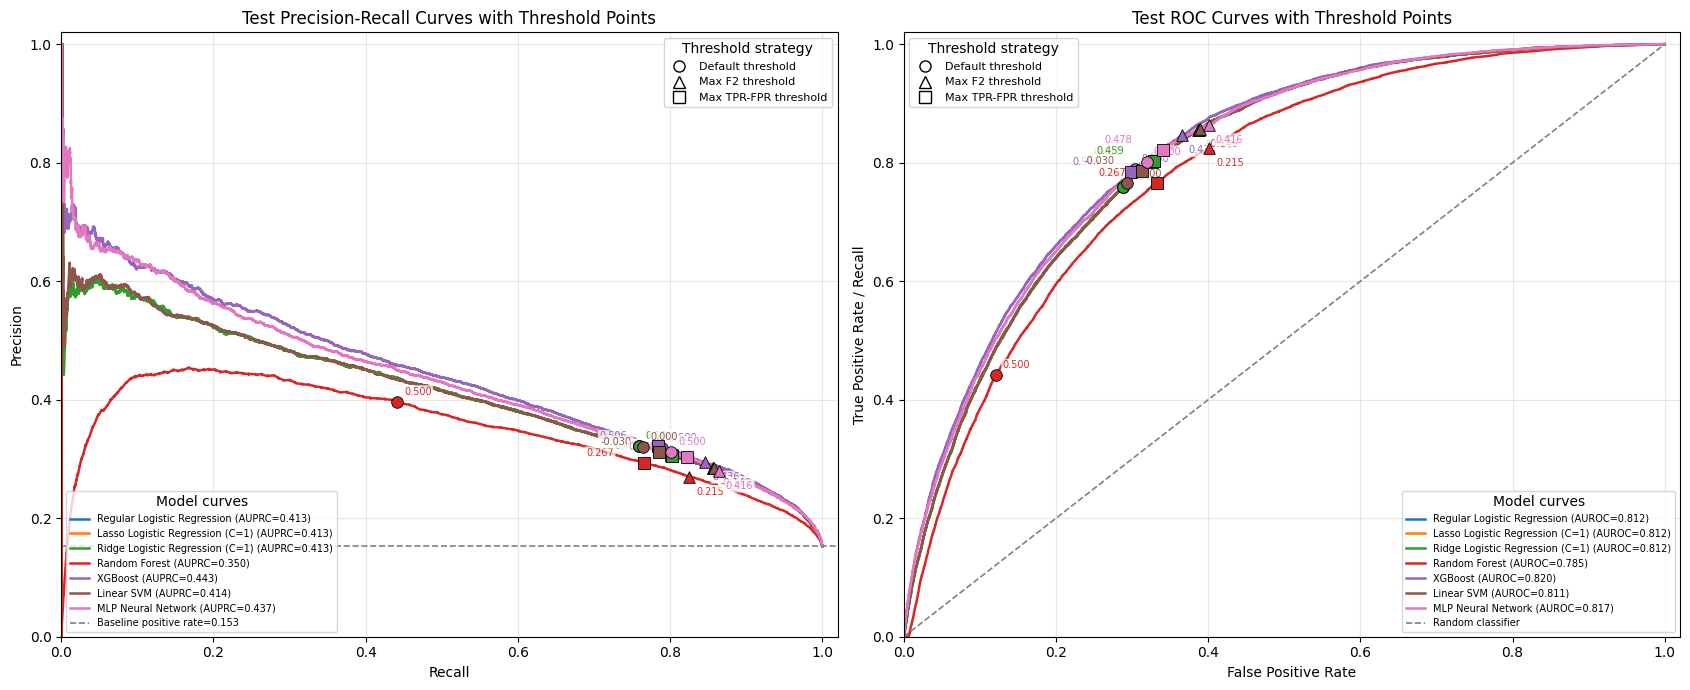

In [12]:
# ==========================================
# 10. Plot Test PRC and ROC Curves with Threshold Operating Points
# ==========================================

non_baseline_models = [
    model_name
    for model_name in test_predictions_df["Model"].unique()
    if model_name != "Dummy Classifier"
]

model_colors = dict(zip(non_baseline_models, plt.cm.tab10.colors[:len(non_baseline_models)]))
threshold_markers = {
    "Default threshold": "o",
    "Max F2 threshold": "^",
    "Max TPR-FPR threshold": "s",
}
threshold_offsets = {
    "Default threshold": (5, 5),
    "Max F2 threshold": (5, -13),
    "Max TPR-FPR threshold": (-42, 5),
}

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
pr_ax, roc_ax = axes

for model_name in non_baseline_models:
    model_scores = (
        test_predictions_df
        .loc[test_predictions_df["Model"] == model_name]
        .drop_duplicates(subset=["Test Row"])
        .sort_values("Test Row")
    )
    y_true_model = model_scores["y_test"]
    y_score_model = model_scores["y_test_score"]
    color = model_colors[model_name]

    precision_curve, recall_curve, _ = precision_recall_curve(y_true_model, y_score_model)
    fpr_curve, tpr_curve, _ = roc_curve(y_true_model, y_score_model)
    auprc = average_precision_score(y_true_model, y_score_model)
    auroc = roc_auc_score(y_true_model, y_score_model)

    pr_ax.plot(
        recall_curve,
        precision_curve,
        color=color,
        linewidth=1.8,
        label=f"{model_name} (AUPRC={auprc:.3f})",
    )
    roc_ax.plot(
        fpr_curve,
        tpr_curve,
        color=color,
        linewidth=1.8,
        label=f"{model_name} (AUROC={auroc:.3f})",
    )

    model_threshold_points = test_scores_df.loc[test_scores_df["Model"] == model_name].copy()
    model_threshold_points["Test FPR"] = model_threshold_points["FP"] / (
        model_threshold_points["FP"] + model_threshold_points["TN"]
    )

    for _, row in model_threshold_points.iterrows():
        marker = threshold_markers[row["Threshold Strategy"]]
        offset = threshold_offsets[row["Threshold Strategy"]]
        threshold_label = f"{row['Threshold']:.3f}"

        pr_ax.scatter(
            row["Test Recall"],
            row["Test Precision"],
            marker=marker,
            s=70,
            color=color,
            edgecolor="black",
            linewidth=0.6,
            zorder=5,
        )
        pr_ax.annotate(
            threshold_label,
            xy=(row["Test Recall"], row["Test Precision"]),
            xytext=offset,
            textcoords="offset points",
            fontsize=7,
            color=color,
            bbox={"boxstyle": "round,pad=0.15", "fc": "white", "alpha": 0.75, "ec": "none"},
        )

        roc_ax.scatter(
            row["Test FPR"],
            row["Test Recall"],
            marker=marker,
            s=70,
            color=color,
            edgecolor="black",
            linewidth=0.6,
            zorder=5,
        )
        roc_ax.annotate(
            threshold_label,
            xy=(row["Test FPR"], row["Test Recall"]),
            xytext=offset,
            textcoords="offset points",
            fontsize=7,
            color=color,
            bbox={"boxstyle": "round,pad=0.15", "fc": "white", "alpha": 0.75, "ec": "none"},
        )

baseline_precision = y_test.mean()
pr_ax.axhline(
    baseline_precision,
    linestyle="--",
    color="gray",
    linewidth=1.2,
    label=f"Baseline positive rate={baseline_precision:.3f}",
)
roc_ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1.2, label="Random classifier")

pr_ax.set_title("Test Precision-Recall Curves with Threshold Points")
pr_ax.set_xlabel("Recall")
pr_ax.set_ylabel("Precision")
pr_ax.set_xlim(0, 1.02)
pr_ax.set_ylim(0, 1.02)
pr_ax.grid(alpha=0.3)

roc_ax.set_title("Test ROC Curves with Threshold Points")
roc_ax.set_xlabel("False Positive Rate")
roc_ax.set_ylabel("True Positive Rate / Recall")
roc_ax.set_xlim(0, 1.02)
roc_ax.set_ylim(0, 1.02)
roc_ax.grid(alpha=0.3)

strategy_handles = [
    plt.Line2D(
        [0],
        [0],
        marker=marker,
        linestyle="None",
        markerfacecolor="white",
        markeredgecolor="black",
        markersize=8,
        label=strategy,
    )
    for strategy, marker in threshold_markers.items()
]

pr_curve_legend = pr_ax.legend(loc="lower left", fontsize=7, title="Model curves")
pr_ax.add_artist(pr_curve_legend)
pr_ax.legend(handles=strategy_handles, loc="upper right", fontsize=8, title="Threshold strategy")

roc_curve_legend = roc_ax.legend(loc="lower right", fontsize=7, title="Model curves")
roc_ax.add_artist(roc_curve_legend)
roc_ax.legend(handles=strategy_handles, loc="upper left", fontsize=8, title="Threshold strategy")

plt.tight_layout()
plt.show()


In [13]:
# ==========================================
# 11. Top 5 Model-Threshold Choices by Test Recall
# ==========================================

top_5_recall_models_df = (
    test_scores_df
    .sort_values(
        by=["Test Recall", "Test F2", "Test Precision"],
        ascending=[False, False, False],
    )
    .head(5)
    [[
        "Model",
        "Hyperparameters",
        "Threshold Strategy",
        "Threshold",
        "Test Recall",
        "Test Precision",
        "Test F1",
        "Test F2",
        "Test AUPRC",
        "Test AUROC",
        "Test Predicted Positive Rate",
        "TPR - FPR",
    ]]
    .reset_index(drop=True)
)

top_5_recall_models_df.round(6)

,Model,Hyperparameters,Threshold Strategy,Threshold,Test Recall,Test Precision,Test F1,Test F2,Test AUPRC,Test AUROC,Test Predicted Positive Rate,TPR - FPR
0,MLP Neural Network,"BatchNorm + Dense(64, relu) + Dense(32, relu) ...",Max F2 threshold,0.416018,0.863960,0.279790,0.422692,0.609462,0.437306,0.816566,0.471680,0.463005
1,Linear SVM,"StandardScaler + LinearSVC(C=1.0, class_weight...",Max F2 threshold,-0.148894,0.857123,0.284008,0.426647,0.610665,0.414171,0.811148,0.460996,0.467544
2,Ridge Logistic Regression (C=1),StandardScaler + LogisticRegression(l1_ratio=0...,Max F2 threshold,0.402283,0.855983,0.284800,0.427398,0.610931,0.413403,0.811550,0.459103,0.468434
3,Regular Logistic Regression,"StandardScaler + LogisticRegression(C=np.inf, ...",Max F2 threshold,0.402278,0.855983,0.284787,0.427383,0.610919,0.413403,0.811550,0.459125,0.468408
4,Lasso Logistic Regression (C=1),StandardScaler + LogisticRegression(l1_ratio=1...,Max F2 threshold,0.402686,0.855840,0.284982,0.427585,0.611041,0.413400,0.811547,0.458733,0.468702


The top 5 table is ranked by test recall first. Ties or near-ties are then ordered by F2 and precision. This ranking favors screening behavior, so it may prefer models/thresholds that flag many people as positive.